In [37]:
import pandas as pd

file_path = r"C:\Users\ub15-lab-008\Downloads\yellow_tripdata_2023-01.parquet"

df = pd.read_parquet(file_path)

df = df.sample(n=300000, random_state=42)
print("Loaded rows:", len(df))
df.head()

Loaded rows: 300000


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
2790731,2,2023-01-29 17:52:02,2023-01-29 17:56:43,1.0,1.17,1.0,N,262,74,2,7.2,0.0,0.5,0.00,0.0,1.0,11.20,2.5,0.0
666153,1,2023-01-08 15:57:24,2023-01-08 16:02:47,1.0,0.90,1.0,N,229,237,2,6.5,2.5,0.5,0.00,0.0,1.0,10.50,2.5,0.0
1985683,2,2023-01-21 19:38:01,2023-01-21 19:45:02,1.0,0.95,1.0,N,45,261,1,7.9,0.0,0.5,2.38,0.0,1.0,14.28,2.5,0.0
2154231,2,2023-01-23 16:07:31,2023-01-23 16:26:46,5.0,0.88,1.0,N,237,141,1,16.3,2.5,0.5,1.50,0.0,1.0,24.30,2.5,0.0
2493619,2,2023-01-26 21:21:08,2023-01-26 21:24:48,2.0,1.03,1.0,N,229,140,1,6.5,1.0,0.5,2.30,0.0,1.0,13.80,2.5,0.0


In [38]:
clean_df = df[
    (df["trip_distance"] > 0) &
    (df["fare_amount"] > 0) &
    (df["total_amount"] > 0) &
    (df["tpep_dropoff_datetime"] > df["tpep_pickup_datetime"]) &
    (df["passenger_count"] >= 1)
]

print("Raw:", len(df))
print("Clean:", len(clean_df))
print("Removed:", len(df) - len(clean_df))

Raw: 300000
Clean: 282253
Removed: 17747


In [39]:
clean_df["tip_group"] = pd.cut(
    clean_df["tip_amount"],
    bins=[-1, 0, 5, 100],
    labels=["No Tip", "Low Tip", "High Tip"]
)

result = clean_df.groupby("tip_group")["fare_amount"].mean()

print(result)

tip_group
No Tip      19.364903
Low Tip     12.511431
High Tip    39.196825
Name: fare_amount, dtype: float64


In [40]:
payment_result = clean_df.groupby("payment_type")["tip_amount"].mean()

print(payment_result)

payment_type
1    4.167959
2    0.000238
3    0.000000
4    0.003633
Name: tip_amount, dtype: float64


In [41]:
tip_ratio = (clean_df["tip_amount"] / clean_df["fare_amount"]).mean()

print("Average Tip/Fare Ratio:", tip_ratio)

Average Tip/Fare Ratio: 0.20572606982163222


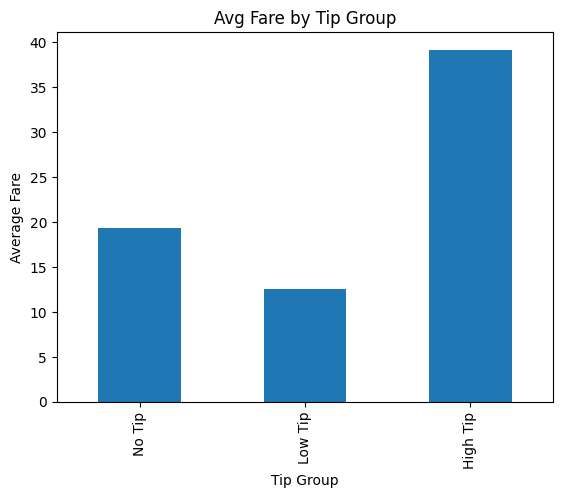

In [42]:
import matplotlib.pyplot as plt

result.plot(kind="bar")
plt.title("Avg Fare by Tip Group")
plt.xlabel("Tip Group")
plt.ylabel("Average Fare")
plt.show()

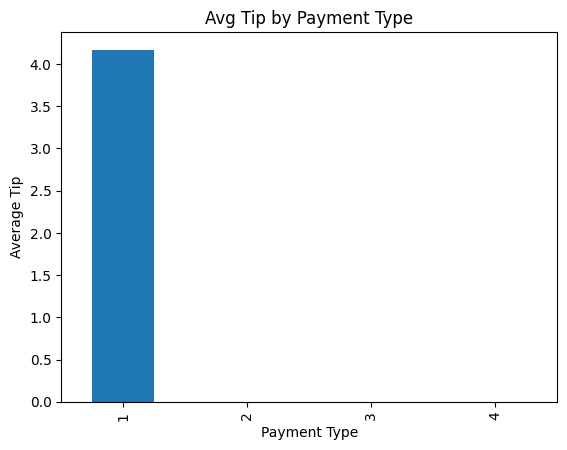

In [43]:
payment_result.plot(kind="bar")
plt.title("Avg Tip by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Average Tip")
plt.show()

In [44]:
clean_df["payment_type"].value_counts()

valid = clean_df[clean_df["payment_type"].isin([1,2,3,4])]

payment_result = valid.groupby("payment_type")["tip_amount"].mean()

print(payment_result)

payment_type
1    4.167959
2    0.000238
3    0.000000
4    0.003633
Name: tip_amount, dtype: float64


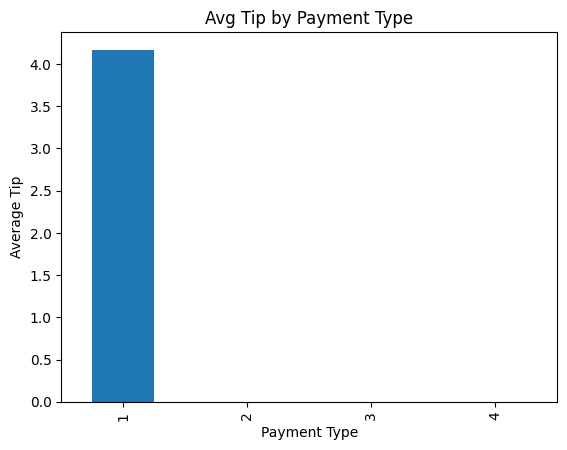

In [45]:
payment_result.plot(kind="bar")
plt.title("Avg Tip by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Average Tip")
plt.show()

In [46]:
filtered = clean_df[(clean_df["payment_type"] == 1) & (clean_df["tip_amount"] > 0)]

filtered["tip_amount"].mean()

np.float64(4.340794943654894)

In [47]:
clean_df["tip_pct"] = clean_df["tip_amount"] / clean_df["fare_amount"]

filtered = clean_df[(clean_df["payment_type"] == 1) & (clean_df["tip_amount"] > 0)]

filtered["tip_pct"].mean()

np.float64(0.2628914724239041)

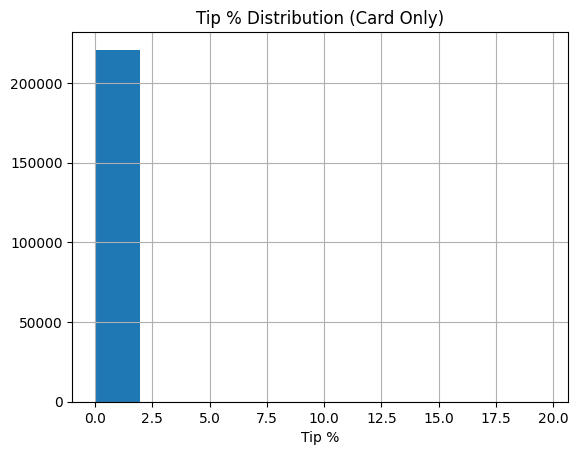

In [48]:
filtered["tip_pct"].hist()
plt.title("Tip % Distribution (Card Only)")
plt.xlabel("Tip %")
plt.show()

In [49]:
filtered2 = filtered[filtered["tip_pct"] < 1]  # remove >100% tips
filtered2["tip_pct"].mean()

np.float64(0.2606776143792936)

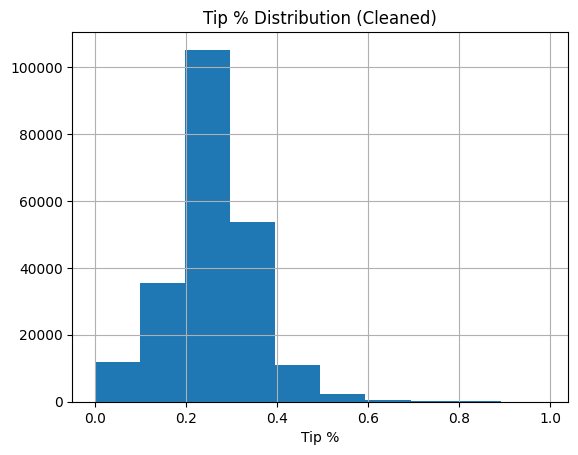

In [50]:
filtered2["tip_pct"].hist()
plt.title("Tip % Distribution (Cleaned)")
plt.xlabel("Tip %")
plt.show()

In [51]:
print("""
We first analyzed tipping using all data, but results were misleading due to missing cash tips.
Then we focused on card payments to remove recording bias.
Finally, we removed extreme values to get a realistic distribution.

This shows that tipping appears high at first, but after cleaning,
most people tip in a moderate range.

Overall, the system is influenced by both real passenger behavior and data limitations,
so conclusions must be made carefully.
""")


We first analyzed tipping using all data, but results were misleading due to missing cash tips.
Then we focused on card payments to remove recording bias.
Finally, we removed extreme values to get a realistic distribution.

This shows that tipping appears high at first, but after cleaning,
most people tip in a moderate range.

Overall, the system is influenced by both real passenger behavior and data limitations,
so conclusions must be made carefully.



In [52]:
#The system reflects both behavioral patterns (tipping habits) and structural biases 
#(payment method and data recording), confirming that it is not purely mechanical.

In [53]:
# Extract time features (hour, day, weekday)
clean_df["pickup_hour"] = clean_df["tpep_pickup_datetime"].dt.hour
clean_df["pickup_day"] = clean_df["tpep_pickup_datetime"].dt.day
clean_df["weekday"] = clean_df["tpep_pickup_datetime"].dt.dayofweek  # 0=Mon

In [54]:
# Hourly aggregation (system-level view)
hourly = clean_df.groupby("pickup_hour").agg({
    "trip_distance": "count",   # volume
    "fare_amount": "mean"
}).rename(columns={"trip_distance": "trip_count"})

hourly

,trip_count,fare_amount
pickup_hour,,
0,7837,19.994508
1,5362,17.676162
2,3815,16.459578
3,2414,17.550000
4,1589,21.930906
5,1584,26.328472
6,3924,22.093165
7,7750,19.001387
8,10580,17.605338


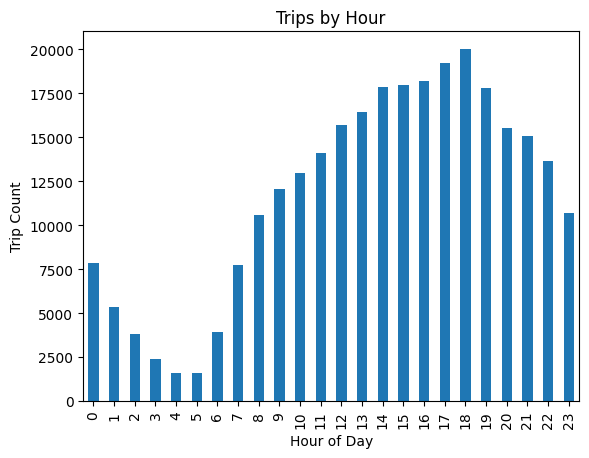

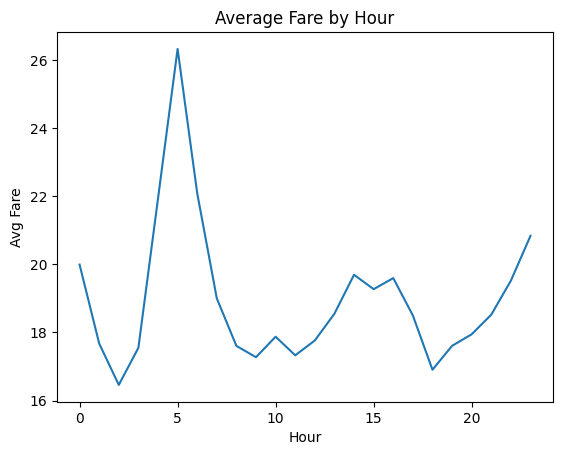

In [55]:
# Trip volume by hour
hourly["trip_count"].plot(kind="bar")
plt.title("Trips by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Trip Count")
plt.show()

# Avg fare by hour
hourly["fare_amount"].plot(kind="line")
plt.title("Average Fare by Hour")
plt.xlabel("Hour")
plt.ylabel("Avg Fare")
plt.show()

In [56]:
#Trips follow a clear daily pattern: high in the evening and low in early morning.
#This shows a stable routine in city travel. Some small changes in fare or volume are random and not consistent,
#so they are just noise, not real patterns.

In [57]:
# Weekly pattern
weekly = clean_df.groupby("weekday").agg({
    "trip_distance": "count",
    "fare_amount": "mean"
}).rename(columns={"trip_distance": "trip_count"})

weekly

,trip_count,fare_amount
weekday,,
0,37116,19.533242
1,44637,18.582139
2,38715,17.960466
3,40930,18.220001
4,40156,18.350717
5,40599,17.455676
6,40100,19.751848


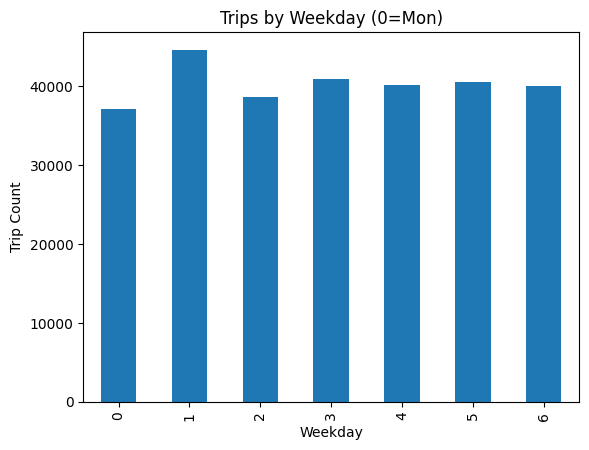

In [58]:
weekly["trip_count"].plot(kind="bar")
plt.title("Trips by Weekday (0=Mon)")
plt.xlabel("Weekday")
plt.ylabel("Trip Count")
plt.show()

In [59]:
#Weekdays show consistent trip counts, with Tuesday highest activity.
#No extreme variation demand is stable across the week.
#Average fare is slightly higher on Monday and Sunday, but overall similar
print("""
The city shows a clear daily cycle with peak and low hours.
Weekly demand remains stable with no major variation.
Some fluctuations are random noise, not real patterns.
Overall, the system is cyclical and stable, not random.
""")


The city shows a clear daily cycle with peak and low hours.
Weekly demand remains stable with no major variation.
Some fluctuations are random noise, not real patterns.
Overall, the system is cyclical and stable, not random.



In [60]:
print("""
Step 1: Choosing parameter (Fare)

We chose fare because it directly affects both passenger behavior and system revenue.
If fare changes, people may travel less or differently, making it a strong factor to test.
""")


Step 1: Choosing parameter (Fare)

We chose fare because it directly affects both passenger behavior and system revenue.
If fare changes, people may travel less or differently, making it a strong factor to test.



In [61]:
print("""
Step 2: Applying policy change

We simulate a small increase in fare (10%).
This represents a realistic policy adjustment in pricing.
""")

sim_df = clean_df.copy()
sim_df["new_fare"] = sim_df["fare_amount"] * 1.10


Step 2: Applying policy change

We simulate a small increase in fare (10%).
This represents a realistic policy adjustment in pricing.



In [62]:
print("""
Step 3: Estimating system reaction

When fares increase, some passengers may reduce trips.
We assume a small drop (5%) in trip volume.
""")

original_trips = len(clean_df)
new_trips = int(original_trips * 0.95)


Step 3: Estimating system reaction

When fares increase, some passengers may reduce trips.
We assume a small drop (5%) in trip volume.



In [63]:
print("""
Step 4: Comparing system output

We compare total revenue before and after the change.
""")

original_revenue = clean_df["fare_amount"].sum()
new_revenue = sim_df["new_fare"].sum() * 0.95

print(f"Original Revenue: {original_revenue:.2f}")
print(f"New Revenue: {new_revenue:.2f}")


Step 4: Comparing system output

We compare total revenue before and after the change.

Original Revenue: 5233154.29
New Revenue: 5468646.23


In [64]:
print("""
The new revenue is higher than the original revenue even after a drop in trips.

This means the increase in fare compensates for the reduction in demand.

The system absorbs the change instead of failing or behaving unpredictably.

Conclusion:
The system is stable and can handle small fare increases without major negative impact.
""")


The new revenue is higher than the original revenue even after a drop in trips.

This means the increase in fare compensates for the reduction in demand.

The system absorbs the change instead of failing or behaving unpredictably.

Conclusion:
The system is stable and can handle small fare increases without major negative impact.



In [66]:
clean_df.to_csv("clean_trips_sample.csv", index=False)

import os

os.path.exists("clean_trips_sample.csv")

True

In [67]:
pd.read_csv("clean_trips_sample.csv").head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,tip_group,tip_pct,pickup_hour,pickup_day,weekday
0,2,2023-01-29 17:52:02,2023-01-29 17:56:43,1.0,1.17,1.0,N,262,74,2,...,0.0,1.0,11.20,2.5,0.0,No Tip,0.000000,17,29,6
1,1,2023-01-08 15:57:24,2023-01-08 16:02:47,1.0,0.90,1.0,N,229,237,2,...,0.0,1.0,10.50,2.5,0.0,No Tip,0.000000,15,8,6
2,2,2023-01-21 19:38:01,2023-01-21 19:45:02,1.0,0.95,1.0,N,45,261,1,...,0.0,1.0,14.28,2.5,0.0,Low Tip,0.301266,19,21,5
3,2,2023-01-23 16:07:31,2023-01-23 16:26:46,5.0,0.88,1.0,N,237,141,1,...,0.0,1.0,24.30,2.5,0.0,Low Tip,0.092025,16,23,0
4,2,2023-01-26 21:21:08,2023-01-26 21:24:48,2.0,1.03,1.0,N,229,140,1,...,0.0,1.0,13.80,2.5,0.0,Low Tip,0.353846,21,26,3
